# Relações

**Módulo:** 01 – Conjuntos e Funções

**Pré-requisitos:** [`012a_conjuntos.ipynb`](012a_conjuntos.ipynb) (operações, notação e pertinência de conjuntos), além do Python básico de [00_fundamentos_e_python/](../00_fundamentos_e_python/) (listas, tuplas, loops)

**Objetivos de aprendizagem:**
- Representar pares ordenados e localizá-los no plano cartesiano.
- Construir o produto cartesiano entre dois conjuntos e calcular sua cardinalidade.
- Identificar uma relação binária como subconjunto de um produto cartesiano, e representá-la de diferentes formas.
- Determinar domínio, contradomínio, imagem e relação inversa de uma relação.
- Verificar se uma relação é reflexiva, simétrica, transitiva ou antissimétrica.

**Tempo estimado:** 50 a 60 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/01_conjuntos_e_funcoes/014a_relacoes.ipynb)

## Quem segue quem

Numa rede social pequena, três pessoas — Ana, Bruno e Clara — seguem umas às outras assim:

```
Ana segue Bruno
Bruno segue Ana
Ana segue Clara
```

Anotando isso como uma lista crua de pares, `("Ana", "Bruno")`, `("Bruno", "Ana")`, `("Ana", "Clara")`, já dá pra perceber algo: **Ana segue Clara, mas Clara não segue Ana de volta**. Só que `("Ana", "Bruno")` e `("Bruno", "Ana")` são pares diferentes — e é exatamente por isso que a ordem dentro de cada par importa: seguir não é a mesma coisa que ser seguido.

E se a rede tivesse 50 pessoas? Escrever "quem segue quem" como uma lista de pares continuaria funcionando — só que ficaria enorme e difícil de enxergar padrões (quem segue muita gente? existe alguém que segue e é seguido por todo mundo?). Esses padrões têm nome: são **propriedades de uma relação**, e é isso que vamos estudar neste notebook.

💡 **Dica:** guarde esse exemplo de "quem segue quem" — ele volta, formalizado, lá no final do notebook.

## Par ordenado

- Um **par ordenado** é escrito (a, b), onde a é a **primeira coordenada** e b é a **segunda coordenada**. A ordem importa — daí o nome.
- **Propriedade fundamental:** (a, b) = (c, d) se, e somente se, a = c **e** b = d.
- Isso é exatamente o que já apareceu no gancho: `("Ana", "Bruno")` e `("Bruno", "Ana")` são pares diferentes, mesmo tendo os "mesmos" elementos — só que em ordem trocada.

📌 **Definição formal:**
- Wikipédia (PT): ["Par ordenado"](https://pt.wikipedia.org/wiki/Par_ordenado)

⚠️ **Erro comum:** confundir o par ordenado (a, b) com o **conjunto** {a, b}. Em conjuntos a ordem não importa e elementos repetidos somem — {2, 3} = {3, 2} — mas em pares ordenados (2, 3) ≠ (3, 2).

**Pergunta de checagem:**
1. Se (x, 5) = (7, y), quanto valem x e y?

In [1]:
par_seguidor = ("Ana", "Bruno")   # Ana segue Bruno
par_seguido = ("Bruno", "Ana")    # Bruno segue Ana

print("par_seguidor:", par_seguidor)
print("par_seguido: ", par_seguido)
print("par_seguidor == par_seguido?", par_seguidor == par_seguido)

# comparando com o comportamento de um conjunto, onde a ordem não importa
conjunto_1 = {"Ana", "Bruno"}
conjunto_2 = {"Bruno", "Ana"}
print("\nconjunto_1 == conjunto_2?", conjunto_1 == conjunto_2)

# a igualdade de pares ordenados: (a, b) = (c, d) <=> a = c e b = d
par_a = (2, 3)
par_b = (2, 3)
par_c = (3, 2)
print("\npar_a == par_b?", par_a == par_b)
print("par_a == par_c?", par_a == par_c)

par_seguidor: ('Ana', 'Bruno')
par_seguido:  ('Bruno', 'Ana')
par_seguidor == par_seguido? False

conjunto_1 == conjunto_2? True

par_a == par_b? True
par_a == par_c? False


## Sistema cartesiano ortogonal

- O **plano cartesiano** é formado por dois eixos perpendiculares: o eixo x (horizontal, das **abscissas**) e o eixo y (vertical, das **ordenadas**). Eles se cruzam num ponto chamado **origem**, (0, 0).
- Os dois eixos dividem o plano em quatro regiões, os **quadrantes**, numerados em sentido anti-horário a partir do canto superior direito:

| Quadrante | x | y |
|---|---|---|
| 1º | positivo | positivo |
| 2º | negativo | positivo |
| 3º | negativo | negativo |
| 4º | positivo | negativo |

- Cada ponto do plano corresponde a exatamente um par ordenado (x, y), e cada par ordenado corresponde a exatamente um ponto — é o par ordenado "ganhando corpo" visualmente.

🕵️ **Curiosidade histórica:** o nome "cartesiano" vem de René Descartes, matemático e filósofo francês do século XVII. A lenda (provavelmente exagerada) conta que ele teve a ideia observando uma mosca andando pelo teto quadriculado do seu quarto — percebendo que a posição dela podia ser descrita por duas distâncias, até cada uma de duas paredes.

**Pergunta de checagem:**
1. Em que quadrante está o ponto (-3, 5)? E o ponto (4, -1)?

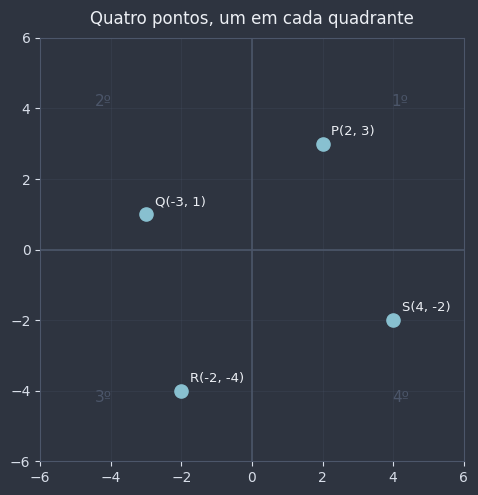

P(2, 3) está no 1º quadrante
Q(-3, 1) está no 2º quadrante
R(-2, -4) está no 3º quadrante
S(4, -2) está no 4º quadrante


In [2]:
import matplotlib.pyplot as plt

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"


def quadrante(x: float, y: float) -> str:
    '''Identifica o quadrante (ou eixo) de um ponto (x, y) do plano cartesiano.'''
    if x == 0 and y == 0:
        return "origem"
    if x == 0:
        return "eixo y"
    if y == 0:
        return "eixo x"
    if x > 0 and y > 0:
        return "1º quadrante"
    if x < 0 and y > 0:
        return "2º quadrante"
    if x < 0 and y < 0:
        return "3º quadrante"
    return "4º quadrante"


def plano_cartesiano(
    pontos: list[tuple[float, float, str]] | None = None,
    limites: tuple[float, float] = (-6, 6),
    titulo: str = "",
    ax=None,
) -> None:
    '''Desenha um plano cartesiano com eixos, quadrantes e pontos nomeados.

    Args:
        pontos: lista de (x, y, rótulo) a marcar no plano.
        limites: intervalo (mínimo, máximo) exibido nos dois eixos.
        titulo: título exibido acima do plano.
        ax: eixo do matplotlib onde desenhar; se None, cria uma figura nova.
    '''
    criou_figura = ax is None
    if criou_figura:
        fig, ax = plt.subplots(figsize=(5.5, 5.5))
        fig.patch.set_facecolor(NORD_FUNDO)
    ax.set_facecolor(NORD_FUNDO)

    minimo, maximo = limites
    ax.axhline(0, color=NORD_LINHA, linewidth=1.2, zorder=1)
    ax.axvline(0, color=NORD_LINHA, linewidth=1.2, zorder=1)
    ax.grid(color=NORD_LINHA, linewidth=0.4, alpha=0.4, zorder=0)

    rotulos_quadrante = {
        "1º": (maximo * 0.7, maximo * 0.7),
        "2º": (minimo * 0.7, maximo * 0.7),
        "3º": (minimo * 0.7, minimo * 0.7),
        "4º": (maximo * 0.7, minimo * 0.7),
    }
    for nome, (x, y) in rotulos_quadrante.items():
        ax.text(x, y, nome, color=NORD_LINHA, fontsize=11, ha="center", va="center")

    if pontos is not None:
        for x, y, rotulo in pontos:
            ax.scatter([x], [y], s=90, color=COR_PONTO, zorder=3)
            rotulo_ponto = f"{rotulo}({x:g}, {y:g})"
            ax.text(x + 0.25, y + 0.25, rotulo_ponto, color=NORD_TEXTO, fontsize=9.5)

    ax.set_xlim(minimo, maximo)
    ax.set_ylim(minimo, maximo)
    ax.set_aspect("equal")
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    if titulo:
        ax.set_title(titulo, color=NORD_TEXTO, pad=10)

    if criou_figura:
        plt.show()


pontos_exemplo = [(2, 3, "P"), (-3, 1, "Q"), (-2, -4, "R"), (4, -2, "S")]
plano_cartesiano(pontos_exemplo, titulo="Quatro pontos, um em cada quadrante")

for x, y, rotulo in pontos_exemplo:
    print(f"{rotulo}({x}, {y}) está no {quadrante(x, y)}")

Use o widget abaixo para mover um ponto pelo plano com os sliders e ver as coordenadas e o quadrante atualizando em tempo real.

In [3]:
import ipywidgets as widgets


def explorar_ponto(x: float, y: float) -> None:
    plano_cartesiano([(x, y, "P")], titulo=f"P({x:g}, {y:g}) — {quadrante(x, y)}")
    print(f"Coordenadas: ({x:g}, {y:g})")
    print(f"Localização: {quadrante(x, y)}")


widgets.interact(
    explorar_ponto,
    x=widgets.FloatSlider(value=3.0, min=-6, max=6, step=0.5, description="x:"),
    y=widgets.FloatSlider(value=2.0, min=-6, max=6, step=0.5, description="y:"),
)

interactive(children=(FloatSlider(value=3.0, description='x:', max=6.0, min=-6.0, step=0.5), FloatSlider(value…

<function __main__.explorar_ponto(x: float, y: float) -> None>

## Produto cartesiano

- 📌 **Definição:** dados dois conjuntos A e B, o **produto cartesiano** A × B é o conjunto de **todos** os pares ordenados (a, b) com a ∈ A e b ∈ B: A × B = {(a, b) | a ∈ A e b ∈ B}.
- **Cardinalidade:** |A × B| = |A| · |B| — cada elemento de A combina com cada elemento de B, exatamente uma vez. (Essa contagem é a mesma ideia do **princípio multiplicativo**, que volta com tudo no módulo de análise combinatória.)

📌 **Definição formal:**
- Wikipédia (PT): ["Produto cartesiano"](https://pt.wikipedia.org/wiki/Produto_cartesiano)

⚠️ **Erro comum:** A × B ≠ B × A, em geral — trocar a ordem dos conjuntos troca a ordem dentro de cada par, e (a, b) ≠ (b, a) quando a ≠ b.

**Pergunta de checagem:**
1. Se A tem 3 elementos e B tem 4, quantos pares tem A × B? E B × A?

In [4]:
import itertools

import pandas as pd

A = {1, 2, 3}
B = {2, 3, 4, 5, 6, 7}

produto_ab = list(itertools.product(sorted(A), sorted(B)))
produto_ba = list(itertools.product(sorted(B), sorted(A)))

print(f"|A| = {len(A)}, |B| = {len(B)}")
print(f"|A x B| = |A| . |B| = {len(A)} . {len(B)} = {len(produto_ab)}")

print("\nA x B == B x A (como conjuntos de pares)?", set(produto_ab) == set(produto_ba))
# 1 ∈ A e 2 ∈ B -> (1, 2) está em A x B
print("(1, 2) está em A x B?", (1, 2) in produto_ab)
# precisaria 1 ∈ B, mas 1 ∉ B -> (1, 2) não está em B x A
print("(1, 2) está em B x A?", (1, 2) in produto_ba)

pd.DataFrame(produto_ab, columns=["a", "b"])

|A| = 3, |B| = 6
|A x B| = |A| . |B| = 3 . 6 = 18

A x B == B x A (como conjuntos de pares)? False
(1, 2) está em A x B? True
(1, 2) está em B x A? False


,a,b
0,1,2
1,1,3
2,1,4
3,1,5
4,1,6
5,1,7
6,2,2
7,2,3
8,2,4
9,2,5


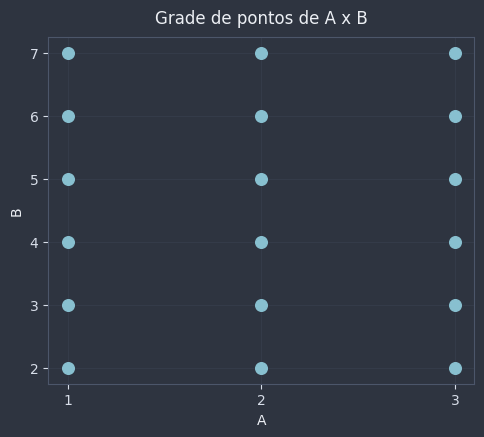

In [5]:
def grade_produto(
    conjunto_a: set,
    conjunto_b: set,
    relacao: list[tuple] | None = None,
    titulo: str = "",
    nome_a: str = "A",
    nome_b: str = "B",
    ax=None,
) -> None:
    '''Desenha a grade de pontos de A x B, destacando os pares de `relacao` se dados.

    Args:
        conjunto_a: conjunto que forma o eixo x da grade.
        conjunto_b: conjunto que forma o eixo y da grade.
        relacao: lista de pares (a, b) a destacar; os demais pares de A x B
            ficam apagados. Se None, todos os pontos usam a mesma cor.
        titulo: título exibido acima da grade.
        nome_a: rótulo do eixo x.
        nome_b: rótulo do eixo y.
        ax: eixo do matplotlib onde desenhar; se None, cria uma figura nova.
    '''
    criou_figura = ax is None
    if criou_figura:
        fig, ax = plt.subplots(figsize=(5.5, 4.5))
        fig.patch.set_facecolor(NORD_FUNDO)
    ax.set_facecolor(NORD_FUNDO)

    lista_a = sorted(conjunto_a)
    lista_b = sorted(conjunto_b)
    pares_relacao = set(relacao) if relacao is not None else None

    for a in lista_a:
        for b in lista_b:
            if pares_relacao is None:
                cor, tamanho, z = COR_PONTO, 70, 3
            elif (a, b) in pares_relacao:
                cor, tamanho, z = COR_DESTAQUE, 95, 4
            else:
                cor, tamanho, z = NORD_LINHA, 35, 2
            ax.scatter([a], [b], s=tamanho, color=cor, zorder=z)

    ax.set_xticks(lista_a)
    ax.set_yticks(lista_b)
    ax.set_xlabel(nome_a, color=NORD_TEXTO)
    ax.set_ylabel(nome_b, color=NORD_TEXTO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    ax.grid(color=NORD_LINHA, linewidth=0.4, alpha=0.4)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    if titulo:
        ax.set_title(titulo, color=NORD_TEXTO, pad=10)

    if criou_figura:
        plt.show()


grade_produto(A, B, titulo="Grade de pontos de A x B")

## Relação binária

- 📌 **Definição:** uma **relação binária** R de A em B é **qualquer** subconjunto de A × B: R ⊆ A × B. Dizer que "a se relaciona com b" (a R b) significa, simplesmente, que o par (a, b) está dentro de R.
- Uma mesma relação pode ser representada de várias formas equivalentes: por uma **sentença aberta** (uma regra, tipo "b = a + 2"), por um **conjunto de pares ordenados**, por um **diagrama de flechas** (sagital), por uma **tabela**, ou por um **gráfico** no plano.

🤓 **Fato curioso:** para A e B finitos, o número de relações **possíveis** entre eles é 2^(|A|·|B|) — cada um dos |A|·|B| pares de A × B ou entra ou não entra em R, de forma independente um do outro. Com |A| = 3 e |B| = 6, já são 2¹⁸ = 262144 relações possíveis! (Essa contagem é uma prévia do módulo de análise combinatória.)

**Pergunta de checagem:**
1. Se A × B tem 5 pares, quantas relações diferentes de A em B existem?

Regra: b = a + 2
R = [(1, 3), (2, 4), (3, 5)]
|R| = 3 (de um total de 18 pares em A x B)


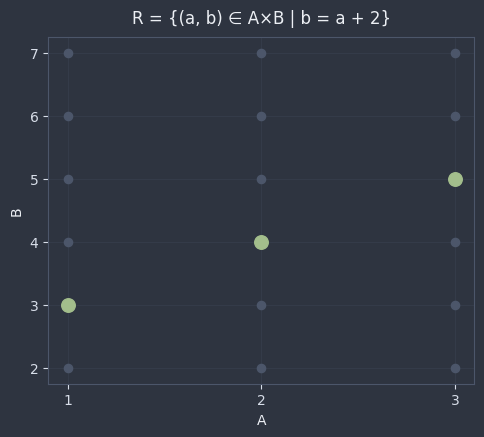

In [6]:
def satisfaz_regra(par: tuple[int, int]) -> bool:
    '''Regra que define a relação: o segundo elemento é 2 a mais que o primeiro.'''
    a, b = par
    return b == a + 2


relacao_r = [par for par in produto_ab if satisfaz_regra(par)]

print("Regra: b = a + 2")
print("R =", relacao_r)
print(f"|R| = {len(relacao_r)} (de um total de {len(produto_ab)} pares em A x B)")

grade_produto(A, B, relacao=relacao_r, titulo="R = {(a, b) ∈ A×B | b = a + 2}")

A mesma relação R, em suas cinco formas de representação:

| Forma | Representação |
|---|---|
| Sentença aberta | b = a + 2 |
| Pares ordenados | {(1, 3), (2, 4), (3, 5)} |
| Tabela | a = 1 ↦ b = 3  ·  a = 2 ↦ b = 4  ·  a = 3 ↦ b = 5 |
| Gráfico | o gráfico em destaque acima |
| Diagrama de flechas | o diagrama a seguir |

O **diagrama de flechas** (ou diagrama sagital) desenha A e B como duas colunas de pontos, com uma flecha ligando a a b sempre que (a, b) ∈ R. Primeiro, a versão estática de R; depois, um widget para você montar sua própria relação escolhendo os pares — o diagrama e a grade atualizam juntos.

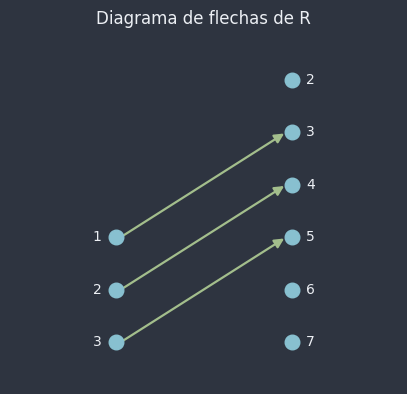

In [7]:
from matplotlib.patches import FancyArrowPatch


def diagrama_sagital(
    lista_a: list,
    lista_b: list,
    relacao: list[tuple],
    titulo: str = "",
    ax=None,
) -> None:
    '''Desenha um diagrama de flechas (sagital) entre duas colunas de nós, A e B.

    Args:
        lista_a: elementos do conjunto de partida, exibidos na coluna esquerda.
        lista_b: elementos do conjunto de chegada, exibidos na coluna direita.
        relacao: lista de pares (a, b) a ligar com uma flecha.
        titulo: título exibido acima do diagrama.
        ax: eixo do matplotlib onde desenhar; se None, cria uma figura nova.
    '''
    criou_figura = ax is None
    if criou_figura:
        fig, ax = plt.subplots(figsize=(5, 4.5))
        fig.patch.set_facecolor(NORD_FUNDO)
    ax.set_facecolor(NORD_FUNDO)

    y_a = {a: i for i, a in enumerate(reversed(lista_a))}
    y_b = {b: i for i, b in enumerate(reversed(lista_b))}
    x_a, x_b = 0.0, 1.0

    for a, y in y_a.items():
        ax.scatter([x_a], [y], s=110, color=COR_PONTO, zorder=3)
        ax.text(
            x_a - 0.08, y, str(a), color=NORD_TEXTO,
            fontsize=10, ha="right", va="center",
        )
    for b, y in y_b.items():
        ax.scatter([x_b], [y], s=110, color=COR_PONTO, zorder=3)
        ax.text(
            x_b + 0.08, y, str(b), color=NORD_TEXTO,
            fontsize=10, ha="left", va="center",
        )

    for a, b in relacao:
        if a in y_a and b in y_b:
            seta = FancyArrowPatch(
                (x_a + 0.03, y_a[a]), (x_b - 0.03, y_b[b]),
                arrowstyle="-|>", mutation_scale=14,
                color=COR_DESTAQUE, linewidth=1.6, zorder=2,
            )
            ax.add_patch(seta)

    ax.set_xlim(-0.6, 1.6)
    margem = 0.8
    altura = max(len(lista_a), len(lista_b)) - 1 + margem
    ax.set_ylim(-margem, altura)
    ax.axis("off")
    if titulo:
        ax.set_title(titulo, color=NORD_TEXTO, pad=10)

    if criou_figura:
        plt.show()


diagrama_sagital(sorted(A), sorted(B), relacao_r, titulo="Diagrama de flechas de R")

In [8]:
opcoes_pares_ab = [(f"({a}, {b})", (a, b)) for a, b in produto_ab]


def explorar_relacao(pares: tuple[tuple[int, int], ...]) -> None:
    relacao = list(pares)
    print(f"R = {relacao}")
    print(f"|R| = {len(relacao)}")

    fig, (eixo_grade, eixo_sagital) = plt.subplots(1, 2, figsize=(11, 4.3))
    fig.patch.set_facecolor(NORD_FUNDO)
    grade_produto(A, B, relacao=relacao, titulo="R na grade de A × B", ax=eixo_grade)
    diagrama_sagital(
        sorted(A), sorted(B), relacao,
        titulo="R no diagrama de flechas", ax=eixo_sagital,
    )
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_relacao,
    pares=widgets.SelectMultiple(
        options=opcoes_pares_ab,
        value=tuple(relacao_r),
        description="pares de R:",
        layout=widgets.Layout(width="160px", height="180px"),
    ),
)

interactive(children=(SelectMultiple(description='pares de R:', index=(1, 8, 15), layout=Layout(height='180px'…

<function __main__.explorar_relacao(pares: tuple) -> None>

## Domínio, contradomínio e imagem

- 📌 **Definições**, para uma relação R ⊆ A × B:
    - **Domínio**: o conjunto de partida, A.
    - **Contradomínio**: o conjunto de chegada, B.
    - **Imagem**: o subconjunto do contradomínio **efetivamente atingido** por algum par de R — ou seja, {b ∈ B | existe a ∈ A com (a, b) ∈ R}.

⚠️ **Erro comum — o ponto mais confuso deste notebook:** contradomínio **não é o mesmo** que imagem. O contradomínio é o "território declarado" (todo o B), enquanto a imagem é só a parte desse território que a relação realmente visita. **Imagem ⊆ Contradomínio sempre**, mas a igualdade não é garantida.

**Pergunta de checagem:**
1. Na relação R = {(1, 3), (2, 4), (3, 5)}, de A = {1, 2, 3} em B = {2, 3, 4, 5, 6, 7}: existe algum elemento de B que fica de fora da imagem? Por que a imagem é "menor" que o contradomínio aqui?

In [9]:
# por definição, domínio = conjunto de partida, e contradomínio = conjunto de chegada
dominio_r = A
contradominio_r = B
imagem_r = {b for a, b in relacao_r}    # valores de B efetivamente atingidos por R
buracos_r = contradominio_r - imagem_r  # elementos do contradomínio fora da imagem

print("Domínio:      ", sorted(dominio_r))
print("Contradomínio:", sorted(contradominio_r))
print("Imagem:       ", sorted(imagem_r))
print("\nImagem == Contradomínio?", imagem_r == contradominio_r)
print("Elementos do contradomínio fora da imagem ('buracos'):", sorted(buracos_r))

Domínio:       [1, 2, 3]
Contradomínio: [2, 3, 4, 5, 6, 7]
Imagem:        [3, 4, 5]

Imagem == Contradomínio? False
Elementos do contradomínio fora da imagem ('buracos'): [2, 6, 7]


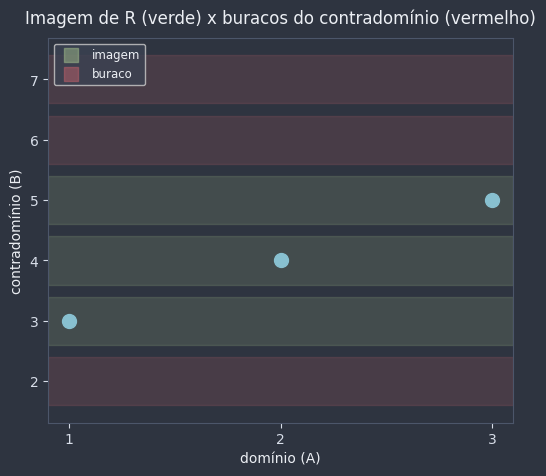

In [10]:
def projecao_dominio_imagem(
    conjunto_a: set,
    contradominio: set,
    relacao: list[tuple],
    titulo: str = "",
) -> None:
    '''Plota a relação e sombreia o contradomínio, distinguindo imagem de "buracos".'''
    fig, ax = plt.subplots(figsize=(6, 5))
    fig.patch.set_facecolor(NORD_FUNDO)
    ax.set_facecolor(NORD_FUNDO)

    imagem = {b for _, b in relacao}
    lista_a = sorted(conjunto_a)
    lista_b = sorted(contradominio)

    for b in lista_b:
        cor = COR_DESTAQUE if b in imagem else COR_ALERTA
        ax.axhspan(b - 0.4, b + 0.4, color=cor, alpha=0.18, zorder=0)

    for a, b in relacao:
        ax.scatter([a], [b], s=100, color=COR_PONTO, zorder=3)

    ax.set_xticks(lista_a)
    ax.set_yticks(lista_b)
    ax.set_xlabel("domínio (A)", color=NORD_TEXTO)
    ax.set_ylabel("contradomínio (B)", color=NORD_TEXTO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    if titulo:
        ax.set_title(titulo, color=NORD_TEXTO, pad=10)

    ax.scatter([], [], s=100, color=COR_DESTAQUE, alpha=0.5, marker="s", label="imagem")
    ax.scatter(
        [], [], s=100, color=COR_ALERTA, alpha=0.5, marker="s", label="buraco",
    )
    ax.legend(
        facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, loc="upper left", fontsize=8.5,
    )

    plt.show()


projecao_dominio_imagem(
    A, B, relacao_r, titulo="Imagem de R (verde) x buracos do contradomínio (vermelho)",
)

## Relação inversa

- 📌 **Definição:** a **relação inversa** de R é R⁻¹ = {(b, a) | (a, b) ∈ R}. Ou seja: inverte-se a ordem de cada par.
- R⁻¹ é uma relação de B em A: os papéis trocam de lugar — o domínio de R⁻¹ é o contradomínio de R, e o contradomínio de R⁻¹ é o domínio de R.

**Pergunta de checagem:**
1. Se R = {(1, 3), (2, 4)}, quem é R⁻¹? Qual é o domínio de R⁻¹?

R    = [(1, 3), (2, 4), (3, 5)]
R⁻¹  = [(3, 1), (4, 2), (5, 3)]


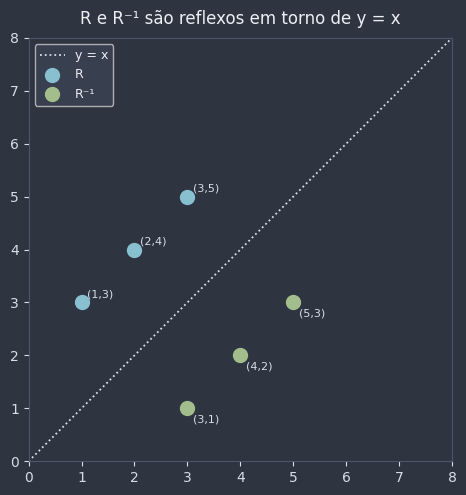

In [11]:
relacao_r_inversa = [(b, a) for a, b in relacao_r]

print("R    =", relacao_r)
print("R⁻¹  =", relacao_r_inversa)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
fig.patch.set_facecolor(NORD_FUNDO)
ax.set_facecolor(NORD_FUNDO)

limite = max(max(A), max(B)) + 1
ax.plot(
    [0, limite], [0, limite], color=NORD_TEXTO_SEC,
    linestyle=":", linewidth=1.3, zorder=1, label="y = x",
)

xs_r, ys_r = zip(*relacao_r, strict=True)
xs_ri, ys_ri = zip(*relacao_r_inversa, strict=True)
ax.scatter(xs_r, ys_r, s=100, color=COR_PONTO, zorder=3, label="R")
ax.scatter(xs_ri, ys_ri, s=100, color=COR_DESTAQUE, zorder=3, label="R⁻¹")

for a, b in relacao_r:
    ax.annotate(
        f"({a},{b})", (a, b), color=NORD_TEXTO_SEC, fontsize=8,
        xytext=(4, 4), textcoords="offset points",
    )
for b, a in relacao_r_inversa:
    ax.annotate(
        f"({b},{a})", (b, a), color=NORD_TEXTO_SEC, fontsize=8,
        xytext=(4, -10), textcoords="offset points",
    )

ax.set_xlim(0, limite)
ax.set_ylim(0, limite)
ax.set_aspect("equal")
ax.tick_params(colors=NORD_TEXTO_SEC)
for spine in ax.spines.values():
    spine.set_color(NORD_LINHA)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, loc="upper left", fontsize=9)
ax.set_title("R e R⁻¹ são reflexos em torno de y = x", color=NORD_TEXTO, pad=10)
plt.show()

## Relação em A e suas propriedades

- 📌 **Definição:** quando o conjunto de partida e o de chegada são o **mesmo** conjunto A, dizemos que R é uma **relação em A** (R ⊆ A × A). É o caso do "quem segue quem" do início do notebook: pessoas se relacionando com outras pessoas do mesmo grupo.
- Para relações em A, quatro propriedades aparecem o tempo todo:

| Propriedade | Condição formal | Exemplo | Contraexemplo |
|---|---|---|---|
| **Reflexiva** | ∀a ∈ A, (a, a) ∈ R | "≤" em {1,2,3}: todo número é ≤ ele mesmo | "<" em {1,2,3}: 1 < 1 é falso |
| **Simétrica** | (a, b) ∈ R ⟹ (b, a) ∈ R | "é amigo de" (mútua): Ana amiga de Bruno ⟹ Bruno amigo de Ana | "segue": Ana segue Clara não garante que Clara segue Ana |
| **Transitiva** | (a, b) ∈ R e (b, c) ∈ R ⟹ (a, c) ∈ R | "≤": a ≤ b e b ≤ c ⟹ a ≤ c | "é pai de": Ana é pai de Bruno, Bruno é pai de Clara, mas Ana não é pai de Clara (é avó) |
| **Antissimétrica** | (a, b) ∈ R e (b, a) ∈ R ⟹ a = b | "≤": a ≤ b e b ≤ a só acontece se a = b | "é amigo de" (mútua): Ana amiga de Bruno e Bruno amigo de Ana, mas Ana ≠ Bruno |

⚠️ **Erro comum:** simétrica **não é o "oposto"** de antissimétrica — uma relação pode não ser nem uma, nem outra. É justamente o caso do "segue": Ana ↔ Bruno é mútuo, mas Ana → Clara não é, então a relação não é totalmente simétrica nem totalmente antissimétrica.

**Pergunta de checagem:**
1. Dê uma relação que seja simétrica mas não reflexiva. (Dica: pense em "é amigo de", permitindo que alguém não seja necessariamente amigo de si mesmo.)

In [12]:
def eh_reflexiva(elementos: set, pares: list[tuple]) -> bool:
    '''Verifica se, para todo a em elementos, o par (a, a) está em pares.'''
    conjunto_pares = set(pares)
    return all((a, a) in conjunto_pares for a in elementos)


def eh_simetrica(pares: list[tuple]) -> bool:
    '''Verifica se (a, b) em pares implica (b, a) em pares, para todo par.'''
    conjunto_pares = set(pares)
    return all((b, a) in conjunto_pares for a, b in conjunto_pares)


def eh_transitiva(pares: list[tuple]) -> bool:
    '''Verifica se (a, b) e (b, c) em pares implica (a, c) em pares.'''
    conjunto_pares = set(pares)
    for a, b in conjunto_pares:
        for b2, c in conjunto_pares:
            if b == b2 and (a, c) not in conjunto_pares:
                return False
    return True


def eh_antissimetrica(pares: list[tuple]) -> bool:
    '''Verifica se (a, b) e (b, a) em pares implica a == b.'''
    conjunto_pares = set(pares)
    return all(a == b for a, b in conjunto_pares if (b, a) in conjunto_pares)


def classificar_relacao(elementos: set, pares: list[tuple]) -> dict[str, bool]:
    '''Classifica uma relação em A quanto às quatro propriedades clássicas.'''
    pares = list(pares)
    return {
        "reflexiva": eh_reflexiva(elementos, pares),
        "simetrica": eh_simetrica(pares),
        "transitiva": eh_transitiva(pares),
        "antissimetrica": eh_antissimetrica(pares),
    }


pessoas = {"Ana", "Bruno", "Clara"}
segue = [("Ana", "Bruno"), ("Bruno", "Ana"), ("Ana", "Clara")]
print("'segue':", classificar_relacao(pessoas, segue))

numeros = {1, 2, 3}
menor_igual = [(a, b) for a in numeros for b in numeros if a <= b]
print("'<=':   ", classificar_relacao(numeros, menor_igual))

'segue': {'reflexiva': False, 'simetrica': False, 'transitiva': False, 'antissimetrica': False}
'<=':    {'reflexiva': True, 'simetrica': False, 'transitiva': True, 'antissimetrica': True}


Repare como a intuição da tabela bate com o código: "segue" não satisfaz **nenhuma** das quatro propriedades (ninguém segue a si mesmo, Ana → Clara não volta, e não há como encadear os poucos pares para testar transitividade sem violar), enquanto "≤" é reflexiva, transitiva e antissimétrica, mas não simétrica.

Antes do widget, a versão estática da matriz de "segue":

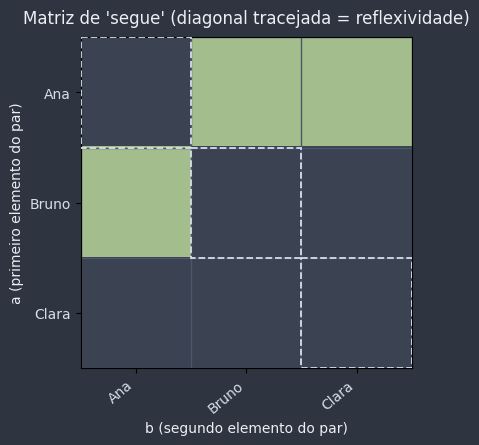

In [13]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle


def matriz_relacao(
    elementos: list, pares: list[tuple], titulo: str = "", ax=None,
) -> None:
    '''Desenha a matriz |A|x|A| de uma relação em A como um grid colorido.

    Args:
        elementos: lista ordenada dos elementos de A (linhas e colunas da matriz).
        pares: pares (a, b) presentes na relação.
        titulo: título exibido acima da matriz.
        ax: eixo do matplotlib onde desenhar; se None, cria uma figura nova.
    '''
    criou_figura = ax is None
    if criou_figura:
        fig, ax = plt.subplots(figsize=(4.3, 4.3))
        fig.patch.set_facecolor(NORD_FUNDO)
    ax.set_facecolor(NORD_FUNDO)

    n = len(elementos)
    conjunto_pares = set(pares)
    matriz = [
        [1 if (a, b) in conjunto_pares else 0 for b in elementos] for a in elementos
    ]

    cmap = ListedColormap([NORD_PAINEL, COR_DESTAQUE])
    ax.imshow(matriz, cmap=cmap, vmin=0, vmax=1)

    for i in range(n):
        ax.add_patch(Rectangle(
            (i - 0.5, i - 0.5), 1, 1, fill=False,
            edgecolor=NORD_TEXTO_SEC, linewidth=1.3, linestyle="--", zorder=3,
        ))

    ax.set_xticks(range(n))
    ax.set_xticklabels(elementos, color=NORD_TEXTO_SEC, rotation=40, ha="right")
    ax.set_yticks(range(n))
    ax.set_yticklabels(elementos, color=NORD_TEXTO_SEC)
    ax.set_xticks([x - 0.5 for x in range(n + 1)], minor=True)
    ax.set_yticks([y - 0.5 for y in range(n + 1)], minor=True)
    ax.grid(which="minor", color=NORD_LINHA, linewidth=1)
    ax.tick_params(which="minor", size=0)
    ax.set_xlabel("b (segundo elemento do par)", color=NORD_TEXTO)
    ax.set_ylabel("a (primeiro elemento do par)", color=NORD_TEXTO)
    if titulo:
        ax.set_title(titulo, color=NORD_TEXTO, pad=10)

    if criou_figura:
        plt.show()


pessoas_lista = sorted(pessoas)
matriz_relacao(
    pessoas_lista, segue,
    titulo="Matriz de 'segue' (diagonal tracejada = reflexividade)",
)

Agora o widget: escolha os pares que formam sua própria relação em A = {Ana, Bruno, Clara} e veja, em tempo real, quais das quatro propriedades ela satisfaz. Tente construir uma relação simétrica mas não reflexiva, ou uma reflexiva e transitiva mas não simétrica.

In [ ]:
opcoes_pares_a = [(f"{a} → {b}", (a, b)) for a in pessoas_lista for b in pessoas_lista]


def explorar_propriedades(pares: tuple[tuple[str, str], ...]) -> None:
    pares = list(pares)
    propriedades = classificar_relacao(pessoas, pares)

    matriz_relacao(pessoas_lista, pares, titulo="Sua relação em A")
    print("R =", pares)
    for nome, valor in propriedades.items():
        emoji = "✅" if valor else "❌"
        print(f"{emoji} {nome}")


widgets.interact(
    explorar_propriedades,
    pares=widgets.SelectMultiple(
        options=opcoes_pares_a,
        value=tuple(segue),
        description="pares:",
        layout=widgets.Layout(width="160px", height="150px"),
    ),
)

interactive(children=(SelectMultiple(description='pares:', index=(1, 3, 2), layout=Layout(height='150px', widt…

<function __main__.explorar_propriedades(pares: tuple) -> None>

## Resumo

- **Par ordenado:** (a, b), com (a, b) = (c, d) ⟺ a = c e b = d. Pares ordenados ≠ conjuntos: (2, 3) ≠ (3, 2), mas {2, 3} = {3, 2}.
- **Produto cartesiano:** A × B = {(a, b) | a ∈ A e b ∈ B}; |A × B| = |A| · |B|; A × B ≠ B × A em geral.
- **Relação binária:** R ⊆ A × B. Pode ser representada por sentença aberta, pares ordenados, diagrama de flechas, tabela ou gráfico.

| Termo | O que é | Sempre igual ao conjunto declarado? |
|---|---|---|
| Domínio | conjunto de partida, A | sim, por definição |
| Contradomínio | conjunto de chegada, B | sim, por definição |
| Imagem | valores de B efetivamente atingidos por R | não — Imagem ⊆ Contradomínio |

- **Relação inversa:** R⁻¹ = {(b, a) | (a, b) ∈ R}; domínio e contradomínio trocam de papel.

| Propriedade | Condição |
|---|---|
| Reflexiva | ∀a ∈ A, (a, a) ∈ R |
| Simétrica | (a, b) ∈ R ⟹ (b, a) ∈ R |
| Transitiva | (a, b) ∈ R e (b, c) ∈ R ⟹ (a, c) ∈ R |
| Antissimétrica | (a, b) ∈ R e (b, a) ∈ R ⟹ a = b |

## Exercícios

**Básico**
1. Identificar domínio, contradomínio e imagem de uma relação dada.
2. Verificar se um par pertence a uma relação dada.
3. Calcular |A × B| para conjuntos dados.

**Intermediário**
1. Construir a relação inversa de uma relação dada.
2. Classificar uma relação em A quanto às quatro propriedades.
3. Escolher a representação mais adequada para uma relação dada.

**Desafio**
1. Dado um conjunto A pequeno, contar quantas relações em A são reflexivas.
2. Construir uma relação em A que seja reflexiva e transitiva, mas não simétrica.

Resolva cada exercício substituindo as reticências `...` e rode a célula de verificação em seguida para conferir sua resposta.

O gabarito comentado de todos os exercícios está em [`014b_relacoes_gabarito.ipynb`](014b_relacoes_gabarito.ipynb) — só dê uma olhada depois de tentar por conta própria.

### Básico

In [ ]:
# Exercício Básico 1: dada a relação R_ex de A_ex em B_ex, determine domínio,
# contradomínio e imagem (como conjuntos)
A_ex = {1, 2, 3}
B_ex = {4, 5, 6, 7}
R_ex = [(1, 4), (2, 5), (2, 6), (3, 4)]

dominio_ex = ...
contradominio_ex = ...
imagem_ex = ...

print(dominio_ex, contradominio_ex, imagem_ex)

In [ ]:
# Verificação
assert dominio_ex == A_ex, (
    "Tente de novo, revise o passo 1: o domínio é sempre o conjunto de partida, A_ex."
)
assert contradominio_ex == B_ex, (
    "Tente de novo, revise o passo 1: o contradomínio é sempre o conjunto B_ex."
)
assert imagem_ex == {4, 5, 6}, (
    "Tente de novo, revise o passo 1: a imagem é o conjunto dos 2os elementos de R_ex."
)
print("Certo!")

In [ ]:
# Exercício Básico 2: usando R_ex do exercício anterior, verifique se os pares
# abaixo pertencem à relação
pertence_1 = ...  # (2, 5) pertence a R_ex?
pertence_2 = ...  # (3, 5) pertence a R_ex?

print(pertence_1, pertence_2)

In [ ]:
# Verificação
assert pertence_1 is True, "Tente de novo: procure (2, 5) na lista R_ex."
assert pertence_2 is False, "Tente de novo: procure (3, 5) na lista R_ex."
print("Certo!")

In [ ]:
# Exercício Básico 3: calcule a cardinalidade do produto cartesiano
conjunto_x = {"p", "q", "r", "s"}
conjunto_y = {1, 2, 3, 4, 5, 6, 7}

cardinalidade_produto = ...  # |conjunto_x x conjunto_y|

print(cardinalidade_produto)

In [ ]:
# Verificação
assert cardinalidade_produto == len(conjunto_x) * len(conjunto_y), (
    "Tente de novo, revise o passo 3: use |A x B| = |A| . |B|."
)
assert cardinalidade_produto == 28, "Confira: |conjunto_x|=4, |conjunto_y|=7, 4.7=28."
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 1: construa a relação inversa de relacao_r3
relacao_r3 = [(1, 2), (3, 4), (5, 6)]

r3_inversa = ...  # lista de pares (b, a) para cada (a, b) em relacao_r3

print(r3_inversa)

In [ ]:
# Verificação
assert set(r3_inversa) == {(2, 1), (4, 3), (6, 5)}, (
    "Tente de novo, revise o passo: inverta cada par (a, b) de relacao_r3 para (b, a)."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 2: classifique a relação abaixo quanto às quatro propriedades
A4 = {1, 2, 3, 4}
pares_r4 = [(1, 1), (2, 2), (3, 3), (4, 4), (1, 2), (2, 1)]

propriedades_r4 = ...  # use classificar_relacao(A4, pares_r4)

print(propriedades_r4)

In [ ]:
# Verificação
esperado = classificar_relacao(A4, pares_r4)
assert propriedades_r4 == esperado, (
    "Tente de novo: use classificar_relacao(A4, pares_r4)."
)
assert propriedades_r4 == {
    "reflexiva": True, "simetrica": True, "transitiva": True, "antissimetrica": False,
}, (
    "Confira: todo elemento se relaciona consigo (reflexiva) e (1,2)/(2,1) quebram a "
    "antissimetria."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 3: escolha a representação mais adequada para cada cenário
REPRESENTACOES = ["diagrama_de_flechas", "formula", "tabela_de_pares"]

cenario_a = "R relaciona 4 amigos, com poucos pares (quem é amigo de quem)"
resposta_a = ...  # uma string de REPRESENTACOES

cenario_b = "R é dada pela fórmula y = 3x, com x variando continuamente entre 0 e 1000"
resposta_b = ...  # uma string de REPRESENTACOES

print(resposta_a, resposta_b)

In [ ]:
# Verificação
assert resposta_a in REPRESENTACOES and resposta_b in REPRESENTACOES, (
    "Tente de novo: escolha uma das strings de REPRESENTACOES para cada resposta."
)
assert resposta_a == "diagrama_de_flechas", (
    "Tente de novo: com poucos elementos discretos, o diagrama de flechas mostra bem "
    "quem se relaciona com quem."
)
assert resposta_b == "formula", (
    "Tente de novo: com domínio contínuo e infinitos valores, listar pares não é "
    "viável — a fórmula é o mais compacto."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 1: conte quantas relações em A5 = {1, 2} são reflexivas
elementos_a5 = {1, 2}
todos_os_pares_a5 = list(itertools.product(elementos_a5, repeat=2))  # 4 pares possíveis


def todas_as_relacoes(pares_possiveis: list[tuple]):
    '''Gera, um a um, todos os subconjuntos de pares_possiveis (o "powerset").'''
    for tamanho in range(len(pares_possiveis) + 1):
        yield from itertools.combinations(pares_possiveis, tamanho)


# Complete: conte quantas relações geradas por todas_as_relacoes(todos_os_pares_a5)
# são reflexivas (use eh_reflexiva)
quantidade_reflexivas = ...

print(quantidade_reflexivas)

In [ ]:
# Verificação
esperado = sum(
    1 for r in todas_as_relacoes(todos_os_pares_a5) if eh_reflexiva(elementos_a5, r)
)
assert quantidade_reflexivas == esperado, (
    "Tente de novo: percorra todas_as_relacoes(todos_os_pares_a5) e conte as que "
    "eh_reflexiva aceita."
)
assert quantidade_reflexivas == 4, (
    "Confira: (1,1) e (2,2) precisam estar presentes; os outros 2 pares são livres "
    "-> 2² = 4 relações."
)
print("Certo!")

In [ ]:
# Exercício Desafio 2: construa uma relação em A6 que seja reflexiva e transitiva,
# mas NÃO simétrica
A6 = {1, 2, 3}

pares_desafio = ...  # lista de pares (a, b) com a, b em A6

print(pares_desafio)

In [ ]:
# Verificação
assert eh_reflexiva(A6, pares_desafio), (
    "Tente de novo: (a, a) precisa estar em pares_desafio para todo a em A6."
)
assert eh_transitiva(pares_desafio), (
    "Tente de novo: garanta que (a,b) e (b,c) em pares_desafio implica (a,c) também."
)
assert not eh_simetrica(pares_desafio), (
    "Tente de novo: pares_desafio não pode ter (b, a) para todo (a, b) — inclua "
    "um par 'de mão única'."
)
print("Certo!")

## Conexões

**Isso depende de:** [`012a_conjuntos.ipynb`](012a_conjuntos.ipynb) (conjuntos, operações e notação)

**Isso será usado em:**
- Funções — toda relação é função? O que falta para uma relação virar função?
- [`12_matematica_discreta/`](../12_matematica_discreta/) (opcional) — as propriedades reflexiva, simétrica e transitiva reaparecem para definir relações de equivalência e relações de ordem